In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

First we perform EDA

In [47]:
data = pd.read_csv('/content/house_rent.csv')
data.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [48]:
data.value_counts()

Posted On   BHK  Rent    Size  Floor            Area Type    Area Locality                            City     Furnishing Status  Tenant Preferred  Bathroom  Point of Contact
2022-07-11  2    12000   550   Ground out of 1  Super Area   Choolaimedu                              Chennai  Unfurnished        Bachelors/Family  2         Contact Owner       1
2022-04-13  3    260000  1800  10 out of 11     Carpet Area  JVPD Scheme                              Mumbai   Furnished          Family            4         Contact Agent       1
2022-04-23  1    6500    800   Ground out of 1  Carpet Area  Santragachi                              Kolkata  Unfurnished        Bachelors/Family  1         Contact Owner       1
                 15000   1000  2 out of 3       Super Area   Barrackpore                              Kolkata  Unfurnished        Bachelors/Family  1         Contact Owner       1
            2    7000    450   1 out of 3       Carpet Area  safuipara                                Kolkata  Furnished          Bachelors         2         Contact Owner       1
                                                                                                                                                                                 ..
2022-04-25  1    6000    220   Ground out of 2  Super Area   Bidhan Pally, Bansdroni                  Kolkata  Furnished          Bachelors/Family  1         Contact Owner       1
2022-04-24  3    15000   1350  1 out of 2       Carpet Area  Annapurna Apartment, Rajarhat Chowmatha  Kolkata  Unfurnished        Family            2         Contact Owner       1
                 12000   1000  Ground out of 1  Super Area   Khardah                                  Kolkata  Unfurnished        Bachelors/Family  2         Contact Owner       1
            2    11000   1000  Ground out of 1  Super Area   Anandapuri, Barrackpore                  Kolkata  Furnished          Bachelors/Family  2         Contact Owner       1
                 9000    650   2 out of 3       Carpet Area  tollygunge Kabardanga                    Kolkata  Unfurnished        Bachelors/Family  1         Contact Owner       1
Name: count, Length: 4746, dtype: int64

In [49]:
data.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [51]:
# Check the data for nulls
data.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [52]:
# unique values of city
data['City'].unique()

array(['Kolkata', 'Mumbai', 'Bangalore', 'Delhi', 'Chennai', 'Hyderabad'],
      dtype=object)

In [53]:
# average rent with city
data.groupby('City')['Rent'].mean()

,Rent
City,
Bangalore,24966.365688
Chennai,21614.092031
Delhi,29461.983471
Hyderabad,20555.048387
Kolkata,11645.173664
Mumbai,85321.204733


<Axes: xlabel='City'>

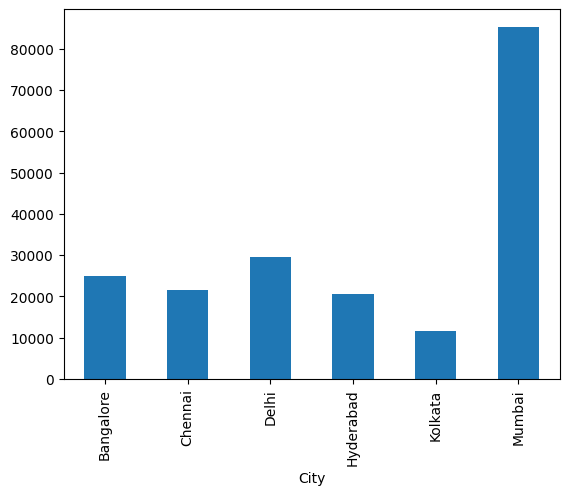

In [54]:
# plot of average rent by city
data.groupby('City')['Rent'].mean().plot(kind='bar')

In [55]:
# average rent by number of bhk
data.groupby('BHK')['Rent'].mean()

,Rent
BHK,
1,14139.223650
2,22113.864018
3,55863.062842
4,168864.555556
5,297500.000000
6,73125.000000


<Axes: xlabel='BHK'>

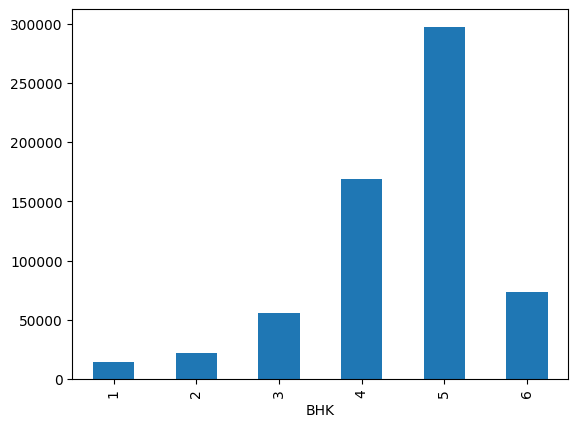

In [56]:
# plot of average rent by bhk
data.groupby('BHK')['Rent'].mean().plot(kind='bar')

In [57]:
# count of values by BHK
data['BHK'].value_counts().sort_index()

,count
BHK,
1,1167
2,2265
3,1098
4,189
5,19
6,8


In [58]:
# average rent by city & bhk
data.groupby(['City','BHK'])['Rent'].mean()

City       BHK
Bangalore  1        9368.333333
           2       16122.041763
           3       61988.580247
           4      113043.478261
Chennai    1        8455.926380
           2       15701.692149
           3       35741.913636
           4       96350.000000
           5       75000.000000
           6      170000.000000
Delhi      1       11332.500000
           2       18878.342520
           3       44141.558442
           4      117455.583333
           5      190000.000000
Hyderabad  1        9753.793103
           2       13877.652466
           3       29337.650206
           4       95730.769231
           5      131666.666667
           6       45000.000000
Kolkata    1        6897.183099
           2       10687.847826
           3       19666.576087
           4       26909.090909
           5       23750.000000
           6       20000.000000
Mumbai     1       29218.843206
           2       57768.195187
           3      122009.242291
           4      279109.589041
           5      442727.272727
Name: Rent, dtype: float64

<Axes: xlabel='City'>

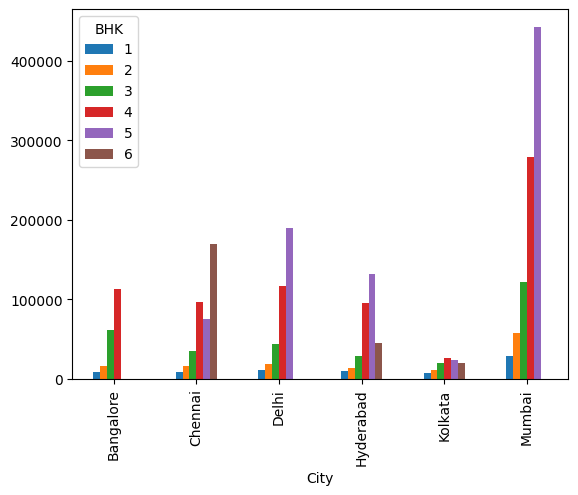

In [59]:
# plot of average rent by city bhk
data.groupby(['City','BHK'])['Rent'].mean().unstack().plot(kind='bar')

In [60]:
# unique values of area type
data['Area Type'].unique()

array(['Super Area', 'Carpet Area', 'Built Area'], dtype=object)

In [61]:
# create a map of area types & replace in data
area_map = {'Super Area':1, 'Carpet Area':2, 'Built Area':3}
data['Area Type'] = data['Area Type'].map(area_map)
data.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,1,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,1,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,1,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,1,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,2,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [62]:
# Unique values of city
data['City'].unique()

array(['Kolkata', 'Mumbai', 'Bangalore', 'Delhi', 'Chennai', 'Hyderabad'],
      dtype=object)

In [63]:
# create a map of city & replace in data
city_map = {'Mumbai':1, 'Bangalore':2, 'Delhi':3, 'Hyderabad':4, 'Chennai':5, 'Kolkata':6}
data['City'] = data['City'].map(city_map)
data.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,1,Bandel,6,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,1,"Phool Bagan, Kankurgachi",6,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,1,Salt Lake City Sector 2,6,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,1,Dumdum Park,6,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,2,South Dum Dum,6,Unfurnished,Bachelors,1,Contact Owner


In [64]:
# select the features for linear regression
X = data[['City','BHK', 'Size']]
y = data['Rent']

In [65]:
# Create training & testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# create model & train
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [67]:
# test it
model.score(X_test, y_test)

0.42730011300356063

In [69]:
# predict
y_pred = model.predict(X_test)

In [73]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 25109.255931167052
